<a href="https://colab.research.google.com/github/elajeans/IMAG2023/blob/main/Oppgave4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

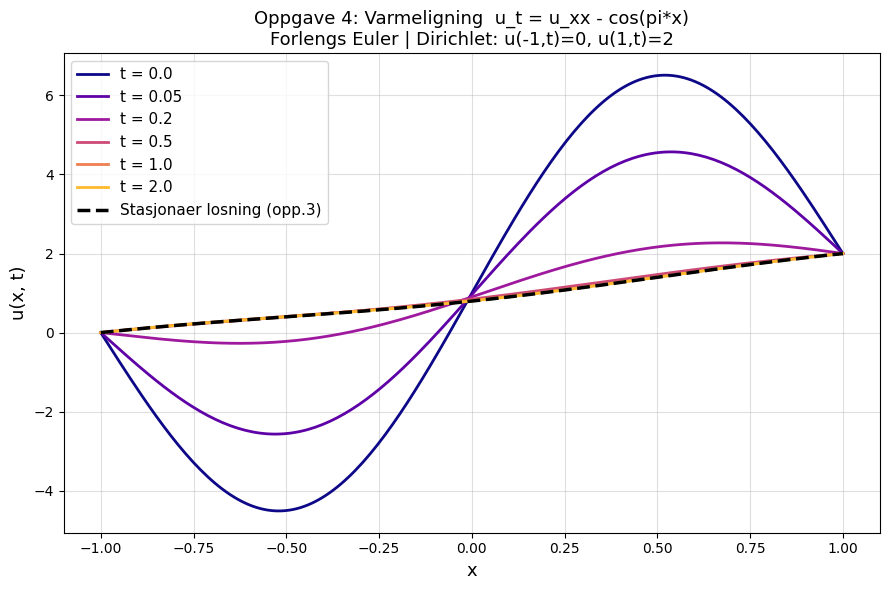

r = dt/dx^2 = 0.40  (< 0.5: stabilt),  Nt = 50501


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# OPPGAVE 4: Varmeligning 1D
# u_t = u_xx - cos(pi*x),  t>=0, -1<x<1
#
# Initialbetingelse:
#   u(x, 0) = 1 + x + 5*sin(pi*x)
#
# Randbetingelser (Dirichletbetingelser, konstante i tid):
#   u(-1, t) = 0   (venstre rand, alle t)
#   u( 1, t) = 2   (hoyre rand,   alle t)
#
# Kildeled: f(x) = cos(pi*x)
# Metode: Forlengs Euler (eksplisitt tidsskjema)

# ------------------------------------------------------------------
# DISKRETISERING
# ------------------------------------------------------------------
# Rom:  dx = 2/(M+1),  punkter x_i = -1 + i*dx
# Tid:  dt velges fra stabilitetsvilkaar
#
# Forlengs Euler-skjema:
#   u_i^n+1 = u_i^n + dt*[ (u_{i-1}^n - 2u_i^n + u_{i+1}^n)/dx^2 - f(x_i) ]
#
# Stabilitetsvilkaar (CFL):
#   r = dt/dx^2 < 0.5   (ellers eksploderer losningen!)
# Vi velger r = 0.4 (trygt under grensen)

M  = 200
dx = 2.0 / (M + 1)
x  = np.linspace(-1, 1, M + 2)
dt = 0.4 * dx**2        # r = 0.4 < 0.5 => stabilt
T  = 2.0
Nt = int(T / dt)

# Initialbetingelse + Dirichletbetingelser
u = 1 + x + 5*np.sin(np.pi * x)
u[0]  = 0   # Dirichlet: u(-1, t) = 0
u[-1] = 2   # Dirichlet: u( 1, t) = 2
f = np.cos(np.pi * x)

# ------------------------------------------------------------------
# TIDSINTEGRASJON: Forlengs Euler
# ------------------------------------------------------------------
save_times = [0.0, 0.05, 0.2, 0.5, 1.0, 2.0]
saved = {0.0: u.copy()}
t = 0.0
for n in range(Nt):
    u_new = u.copy()
    u_new[1:-1] = u[1:-1] + dt*((u[2:] - 2*u[1:-1] + u[:-2])/dx**2 - f[1:-1])
    u_new[0]  = 0   # Dirichlet pa randen (holdes fast)
    u_new[-1] = 2
    u = u_new
    t += dt
    for ts in save_times[1:]:
        if ts not in saved and abs(t - ts) < dt/2:
            saved[ts] = u.copy()

# ------------------------------------------------------------------
# STASJONAER LOSNING (fra Oppgave 3)
# ------------------------------------------------------------------
# Naar t->inf: u_t = 0 => u_xx = cos(pi*x) = Poissonligning (opp.3)
# Losningen konvergerer mot: u(x) = -cos(pi*x)/pi^2 + x + 1 - 1/pi^2
def u_stasjonaer(x):
    return -np.cos(np.pi * x) / np.pi**2 + x + 1 - 1/np.pi**2

# ------------------------------------------------------------------
# PLOT
# ------------------------------------------------------------------
x_fine = np.linspace(-1, 1, 500)
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.plasma(np.linspace(0, 0.85, len(save_times)))
for i, ts in enumerate(save_times):
    if ts in saved:
        ax.plot(x, saved[ts], color=colors[i], lw=2, label=f't = {ts}')
ax.plot(x_fine, u_stasjonaer(x_fine), 'k--', lw=2.5, label='Stasjonaer losning (opp.3)', zorder=5)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('u(x, t)', fontsize=13)
ax.set_title('Oppgave 4: Varmeligning  u_t = u_xx - cos(pi*x)\nForlengs Euler | Dirichlet: u(-1,t)=0, u(1,t)=2', fontsize=13)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
print(f"r = dt/dx^2 = {dt/dx**2:.2f}  (< 0.5: stabilt),  Nt = {Nt}")